In [2]:
import pandas as pd # Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for all charts
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# Paths
CLEAN_PATH = "../data/cleaned/"
FIGURES_PATH = "../outputs/figures/"
os.makedirs(FIGURES_PATH, exist_ok=True)

print("Libraries imported!")

 Libraries imported!


In [3]:

#Load Datasets
co2_emissions  = pd.read_csv(CLEAN_PATH + "co2_emissions_clean.csv")
temp_anomaly   = pd.read_csv(CLEAN_PATH + "temp_anomaly_clean.csv")
energy_mix     = pd.read_csv(CLEAN_PATH + "energy_mix_clean.csv")
carbon_prices  = pd.read_csv(CLEAN_PATH + "carbon_prices_clean.csv", parse_dates=["date"])
climate_events = pd.read_csv(CLEAN_PATH + "climate_events_clean.csv", parse_dates=["date"])

print("All datasets loaded!")
print(f"co2_emissions  : {co2_emissions.shape[0]:,} rows")
print(f"temp_anomaly   : {temp_anomaly.shape[0]:,} rows")
print(f"energy_mix     : {energy_mix.shape[0]:,} rows")
print(f"carbon_prices  : {carbon_prices.shape[0]:,} rows")
print(f"climate_events : {climate_events.shape[0]:,} rows")

All datasets loaded!
co2_emissions  : 1,350 rows
temp_anomaly   : 2,528 rows
energy_mix     : 1,350 rows
carbon_prices  : 15,866 rows
climate_events : 50 rows


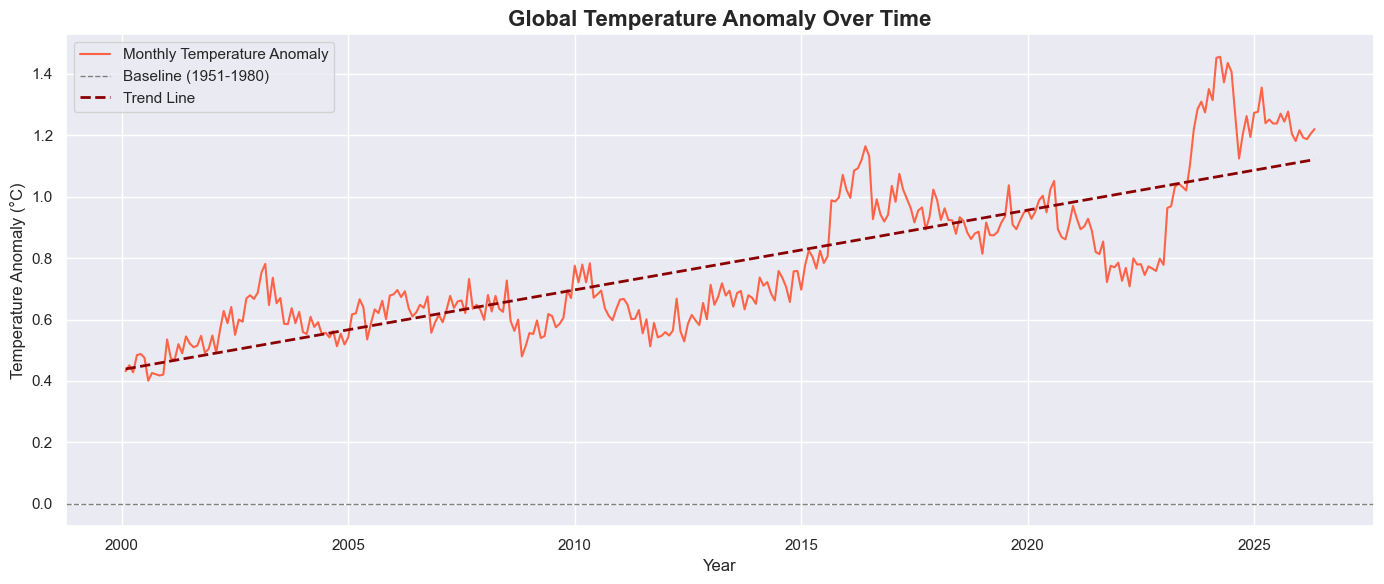

Chart 1 saved!


In [4]:
# Global Temperature Anomaly
# Filter only Global region
global_temp = temp_anomaly[temp_anomaly["region"] == "Global"].copy()

fig, ax = plt.subplots(figsize=(14, 6))

# Temperature line
ax.plot(
    global_temp["year"] + global_temp["month"] / 12,
    global_temp["temp_anomaly_c"],
    color="tomato",
    linewidth=1.5,
    label="Monthly Temperature Anomaly"
)

# Baseline at zero
ax.axhline(0, color="gray", linestyle="--", linewidth=1, label="Baseline (1951-1980)")

# Trend line
z = np.polyfit(
    global_temp["year"] + global_temp["month"] / 12,
    global_temp["temp_anomaly_c"], 1
)
p = np.poly1d(z)
ax.plot(
    global_temp["year"] + global_temp["month"] / 12,
    p(global_temp["year"] + global_temp["month"] / 12),
    color="darkred",
    linewidth=2,
    linestyle="--",
    label="Trend Line"
)

ax.set_title("Global Temperature Anomaly Over Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Temperature Anomaly (°C)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "01_temperature_anomaly.png", dpi=150)
plt.show()
print("Chart 1 saved!")

Top 5 countries: ['China', 'United States', 'India', 'Russia', 'Japan']


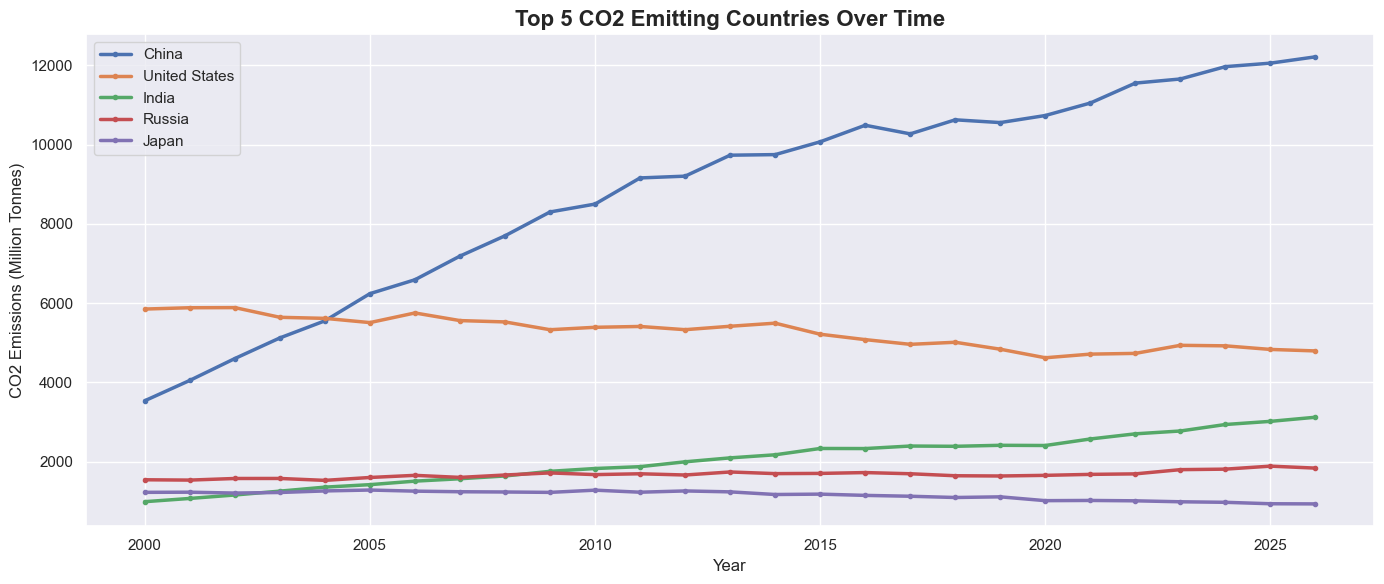

Chart 2 saved!


In [5]:
# Top 5 CO2 Emitting Countries

# Top 5 countries by total CO2
top5_countries = (
    co2_emissions.groupby("country")["co2_emissions_mt"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
print("Top 5 countries:", top5_countries)

# Filter data
top5_data = co2_emissions[co2_emissions["country"].isin(top5_countries)]

fig, ax = plt.subplots(figsize=(14, 6))

for country in top5_countries:
    country_data = top5_data[top5_data["country"] == country]
    ax.plot(
        country_data["year"],
        country_data["co2_emissions_mt"],
        linewidth=2.5,
        marker="o",
        markersize=3,
        label=country
    )

ax.set_title("Top 5 CO2 Emitting Countries Over Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("CO2 Emissions (Million Tonnes)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "02_top5_co2_countries.png", dpi=150)
plt.show()
print("Chart 2 saved!")

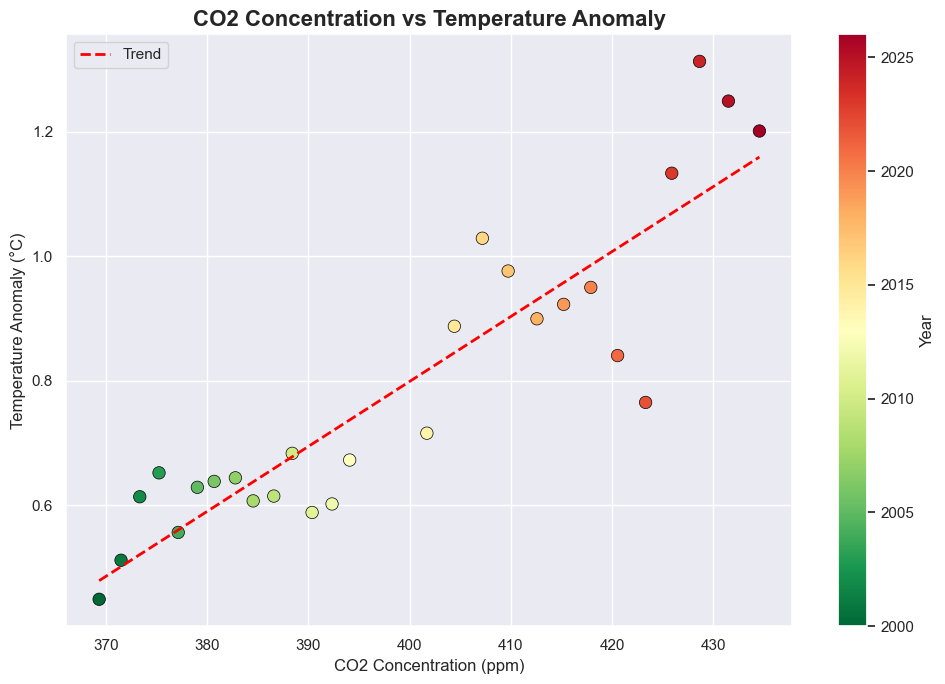

Chart 3 saved!


In [6]:
# CO2 vs Temperature Correlation

# Yearly average temperature
global_temp_yearly = (
    temp_anomaly[temp_anomaly["region"] == "Global"]
    .groupby("year")["temp_anomaly_c"]
    .mean()
    .reset_index()
)

# Yearly average CO2 ppm
co2_ppm_yearly = (
    temp_anomaly[temp_anomaly["region"] == "Global"]
    .groupby("year")["co2_ppm"]
    .mean()
    .reset_index()
)

# Merge both
merged = pd.merge(global_temp_yearly, co2_ppm_yearly, on="year")

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    merged["co2_ppm"],
    merged["temp_anomaly_c"],
    c=merged["year"],
    cmap="RdYlGn_r",
    s=80,
    edgecolors="black",
    linewidth=0.5
)
plt.colorbar(scatter, label="Year")

# Trend line
z = np.polyfit(merged["co2_ppm"], merged["temp_anomaly_c"], 1)
p = np.poly1d(z)
ax.plot(
    sorted(merged["co2_ppm"]),
    p(sorted(merged["co2_ppm"])),
    color="red",
    linewidth=2,
    linestyle="--",
    label="Trend"
)

ax.set_title("CO2 Concentration vs Temperature Anomaly", fontsize=16, fontweight="bold")
ax.set_xlabel("CO2 Concentration (ppm)", fontsize=12)
ax.set_ylabel("Temperature Anomaly (°C)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "03_co2_vs_temperature.png", dpi=150)
plt.show()
print("Chart 3 saved!")

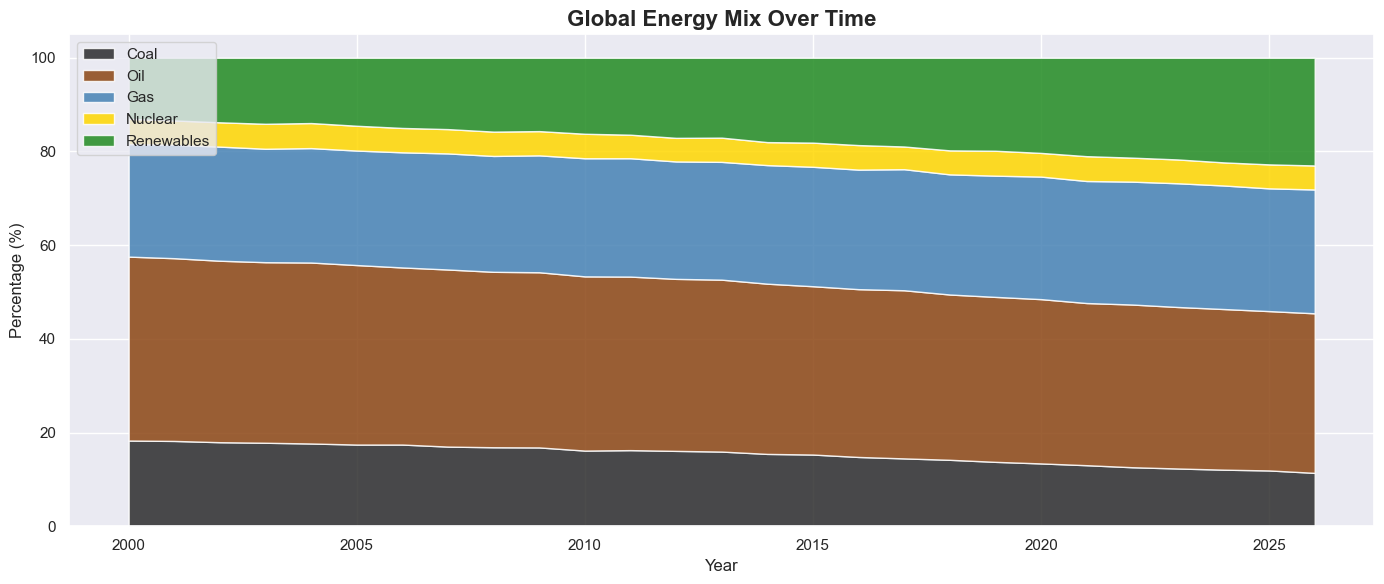

Chart 4 saved!


In [7]:
# Global Energy Mix Over Time


# Average energy mix per year across all countries
energy_yearly = energy_mix.groupby("year")[
    ["coal_pct", "oil_pct", "gas_pct",
     "nuclear_pct", "renewables_total_pct"]
].mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.stackplot(
    energy_yearly.index,
    energy_yearly["coal_pct"],
    energy_yearly["oil_pct"],
    energy_yearly["gas_pct"],
    energy_yearly["nuclear_pct"],
    energy_yearly["renewables_total_pct"],
    labels=["Coal", "Oil", "Gas", "Nuclear", "Renewables"],
    colors=["#2c2c2c", "#8B4513", "#4682B4", "#FFD700", "#228B22"],
    alpha=0.85
)

ax.set_title("Global Energy Mix Over Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_PATH + "04_global_energy_mix.png", dpi=150)
plt.show()
print("Chart 4 saved!")

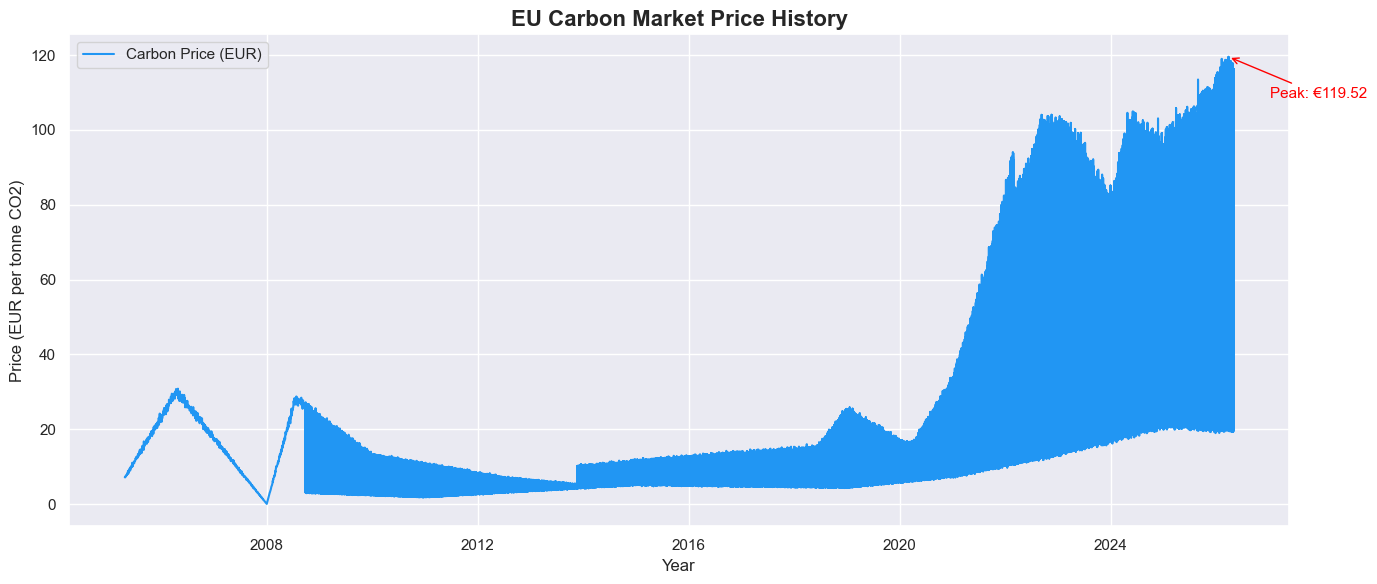

Chart 5 saved!


In [8]:

# Carbon Price History


fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    carbon_prices["date"],
    carbon_prices["price"],
    color="#2196F3",
    linewidth=1.5,
    label="Carbon Price (EUR)"
)

# Highlight peak price
max_price_row = carbon_prices.loc[carbon_prices["price"].idxmax()]
ax.annotate(
    f'Peak: €{max_price_row["price"]:.2f}',
    xy=(max_price_row["date"], max_price_row["price"]),
    xytext=(30, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11,
    color="red"
)

ax.set_title("EU Carbon Market Price History", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Price (EUR per tonne CO2)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "05_carbon_price_history.png", dpi=150)
plt.show()
print("Chart 5 saved!")

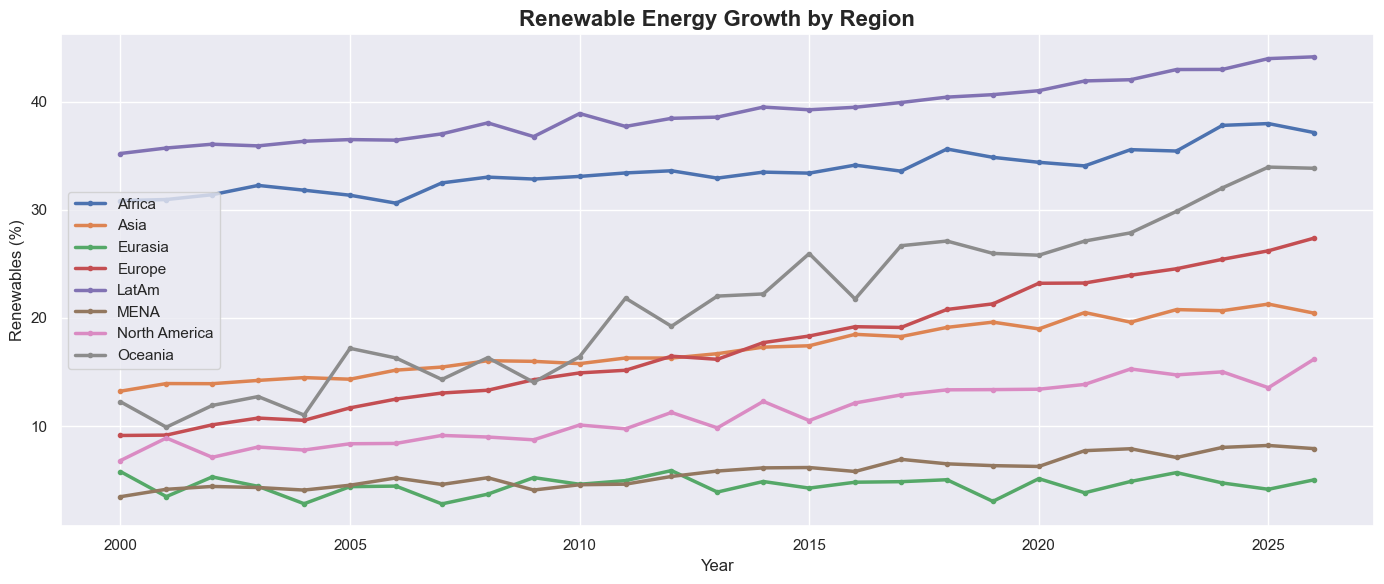

Chart 6 saved!


In [9]:
# Renewable Energy Growth by Region


# Average renewables per region per year
renewables_region = (
    energy_mix.groupby(["year", "region"])["renewables_total_pct"]
    .mean()
    .reset_index()
)

regions = renewables_region["region"].unique()

fig, ax = plt.subplots(figsize=(14, 6))

for region in regions:
    region_data = renewables_region[renewables_region["region"] == region]
    ax.plot(
        region_data["year"],
        region_data["renewables_total_pct"],
        linewidth=2.5,
        marker="o",
        markersize=3,
        label=region
    )

ax.set_title("Renewable Energy Growth by Region", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Renewables (%)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "06_renewables_by_region.png", dpi=150)
plt.show()
print("Chart 6 saved!")